In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df_index = pd.read_csv('multiple_linear_regression_dataset.csv')
df_index.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2006,9,3.707344,8.910212,936.191239
1,2019,7,9.457642,5.342916,1501.194918
2,2014,9,3.570428,11.669425,897.466524
3,2010,8,5.428511,6.369268,1083.717912
4,2007,1,7.178680,3.291792,1230.433134


In [3]:
# drop unneccessary columns
df_index.drop(columns = ["year", "month"], axis=1, inplace = True) # inplace makes it saved in the df_index database at the same time

In [4]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,3.707344,8.910212,936.191239
1,9.457642,5.342916,1501.194918
2,3.570428,11.669425,897.466524
3,5.428511,6.369268,1083.717912
4,7.178680,3.291792,1230.433134


In [5]:
## check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

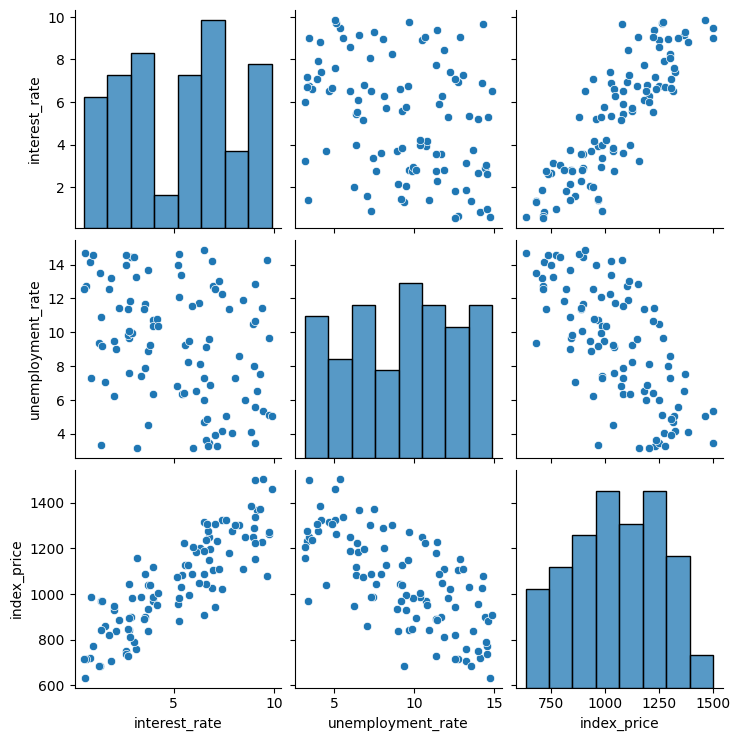

In [6]:
## Visualization
import seaborn as sns
sns.pairplot(df_index)

In [7]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.333772,0.85396
unemployment_rate,-0.333772,1.000000,-0.69457
index_price,0.853960,-0.694570,1.00000


Text(0, 0.5, 'Umemployment rate')

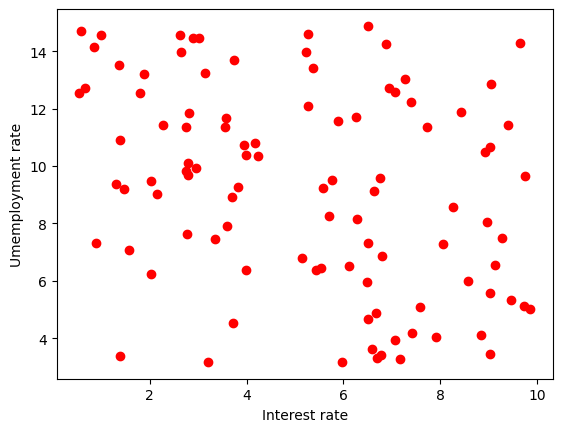

In [8]:
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='r')
plt.xlabel("Interest rate")
plt.ylabel('Umemployment rate')

In [9]:
## Independent and Dependent feature
# X = df_index[['interest_rate', 'unemployment_rate']]   ## one way of doing
X = df_index.iloc[: , :-1]  ## just remove last column
X

,interest_rate,unemployment_rate
0,3.707344,8.910212
1,9.457642,5.342916
2,3.570428,11.669425
3,5.428511,6.369268
4,7.178680,3.291792
...,...,...
95,8.974442,8.035201
96,6.495817,5.972772
97,8.050707,7.271672
98,5.275052,12.094153


In [10]:
y = df_index.iloc[: , -1]
y

0      936.191239
1     1501.194918
2      897.466524
3     1083.717912
4     1230.433134
         ...     
95    1290.549914
96    1189.090324
97    1303.560420
98     984.609389
99    1206.565218
Name: index_price, Length: 100, dtype: float64

In [11]:
# Train-Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.25, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

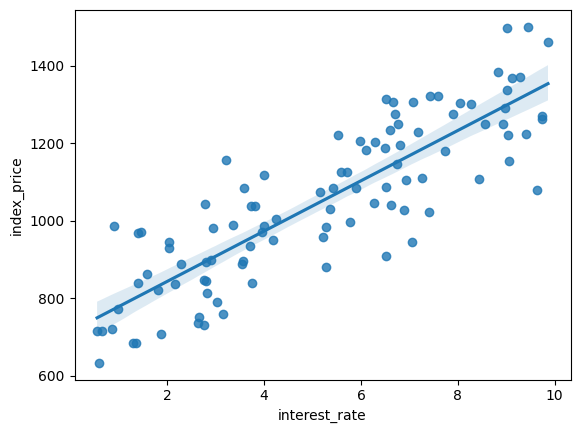

In [16]:
import seaborn as sns

sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])


<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

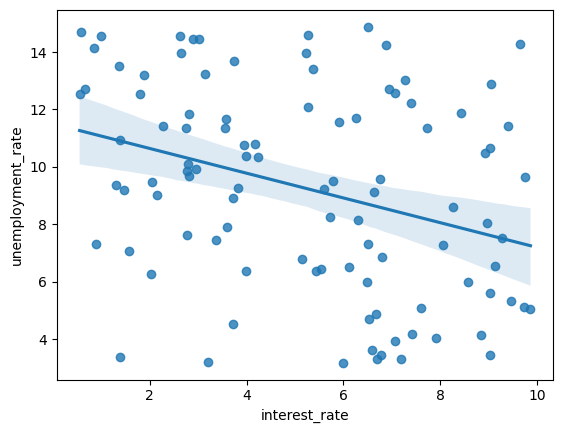

In [17]:
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])

In [18]:
## Standardization : take each ind feature and apply z score:  mean=0 and sd=1  (Zscore= (Xi-mean)/sd)
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  ## used for training data

In [20]:
X_test = scaler.transform(X_test) ## this is used so no data leakeage and train does not know about test data 

In [21]:
## Apply Simple LR
from sklearn.linear_model import LinearRegression

In [22]:
regression = LinearRegression(n_jobs=-1) # njobs run on how many processors are there

In [23]:
regression.fit(X_train, y_train)   

LinearRegression(n_jobs=-1)

In [47]:
print(f"Coefficient or slope : {regression.coef_}")
print(f"Intercept : {regression.intercept_}")

Coefficient or slope : [ 145.44624241 -100.47115654]
Intercept : 1074.069472694847


## Cross-Validation

In [24]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, y_train, scoring= 'neg_mean_squared_error', 
                                   cv = 3)

In [26]:
np.mean(validation_score)

-4378.064495277457

In [27]:
## Prediction
y_pred = regression.predict(X_test)

In [28]:
y_pred

array([ 987.37355587, 1239.86259398, 1227.04834916, 1226.44718211,
        940.28454089,  936.56776468,  891.70381326,  745.57048173,
        986.8663831 ,  966.0497923 ,  947.99846922, 1066.77580369,
        827.69667296,  888.06978145, 1054.06896036, 1325.03191137,
        942.90081149, 1100.58453685,  653.65504613,  700.24790951,
       1141.24716997, 1018.8152402 , 1314.47021921,  872.90452523,
        852.73347495,  649.85366645,  763.39455101, 1210.30995334,
        912.32047957,  622.40322291, 1097.14859545,  834.44836401,
       1251.18334659,  961.62566133, 1296.05582541,  929.03745306,
       1346.96220684, 1225.60092135,  846.85720397,  812.41497854,
       1329.42702748,  812.11286678, 1160.54092613, 1296.61963586,
        941.56293943,  739.20530351, 1057.47015741,  884.81128064,
        962.46646749, 1137.78974315, 1131.77014267, 1137.18947231,
       1347.608967  ,  682.15106061,  763.68804561, 1300.70646249,
       1422.08474608, 1367.85964559, 1172.68840913,  775.06079

In [29]:
## Perfomance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

4055.4470471559816
51.313871854834886
63.682391971061996


In [31]:
# R-Squared
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print(score)

# Adjusted R-Squared
print(1 - (1 - score)*(len(y_test) - 1)/(len(y_test) - X_test.shape[1]-1))

0.9041292839676152
0.9014662085222711


## Assumptions:

Text(0, 0.5, 'y_pred')

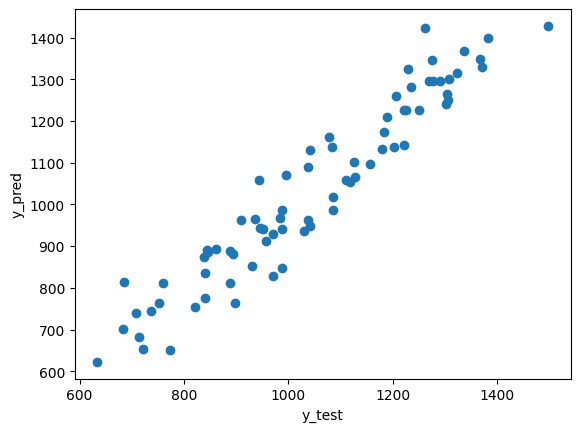

In [35]:
plt.scatter(y_test, y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')

In [33]:
residuals = y_test - y_pred
print(residuals)

83    98.469855
53    63.159814
70    -5.164500
45    -1.111647
44    10.967597
        ...    
79   -19.811275
41   -87.649393
58    70.485335
48   -32.385057
98    16.575375
Name: index_price, Length: 75, dtype: float64


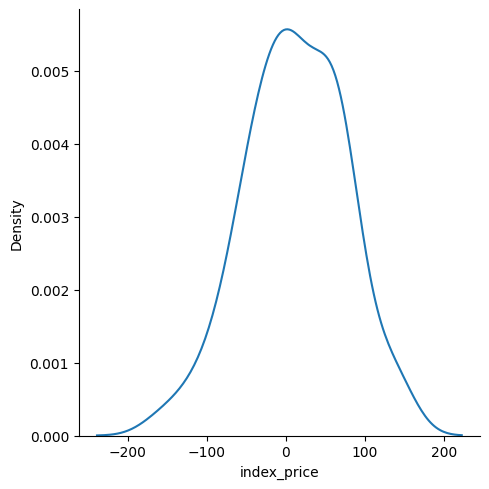

In [41]:
## plot the residuals
sns.displot(residuals, kind = 'kde') # kernel density estimator

#### We see a normal distribution above : means the model created is good.

Text(0, 0.5, 'residuals')

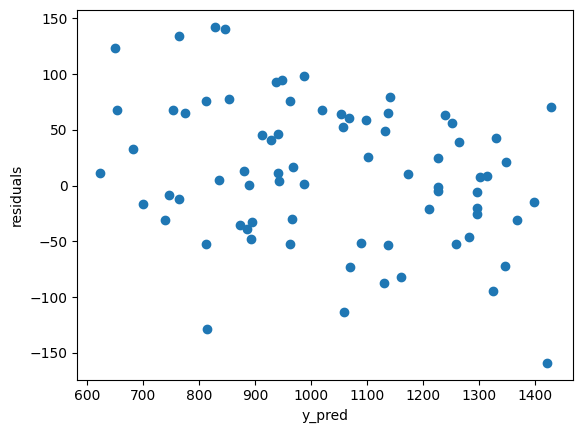

In [42]:
plt.scatter(y_pred, residuals)
plt.xlabel('y_pred')
plt.ylabel('residuals')

#### We see the above scatter plot is uniformly distributed and not following some pattern means that's okay.
#### If it follows some pattern means something is wrong.

## OLS LR:

In [43]:
import statsmodels.api as sm

In [44]:
model = sm.OLS(y_train, X_train).fit()

In [45]:
prediction = model.predict(X_test)
prediction

array([ -86.69591682,  165.79312129,  152.97887647,  152.37770942,
       -133.7849318 , -137.50170802, -182.36565944, -328.49899096,
        -87.20308959, -108.0196804 , -126.07100348,   -7.293669  ,
       -246.37279974, -185.99969124,  -20.00051234,  250.96243868,
       -131.1686612 ,   26.51506416, -420.41442656, -373.82156319,
         67.17769727,  -55.2542325 ,  240.40074652, -201.16494747,
       -221.33599774, -424.21580624, -310.67492169,  136.24048065,
       -161.74899313, -451.66624979,   23.07912276, -239.62110869,
        177.1138739 , -112.44381136,  221.98635272, -145.03201964,
        272.89273414,  151.53144865, -227.21226872, -261.65449416,
        255.35755479, -261.95660591,   86.47145343,  222.55016316,
       -132.50653327, -334.86416918,  -16.59931529, -189.25819205,
       -111.6030052 ,   63.72027045,   57.70066998,   63.11999962,
        273.53949431, -391.91841209, -310.38142708,  226.63698979,
        348.01527338,  293.7901729 ,   98.61893644, -299.00867

In [46]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.032
Model:                            OLS   Adj. R-squared (uncentered):             -0.052
Method:                 Least Squares   F-statistic:                             0.3840
Date:                Thu, 03 Apr 2025   Prob (F-statistic):                       0.685
Time:                        01:14:49   Log-Likelihood:                         -209.98
No. Observations:                  25   AIC:                                      424.0
Df Residuals:                      23   BIC:                                      426.4
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

#### Comparing with sklearn:

In [51]:
print(f"Coefficient or slope : {regression.coef_}")
print(f"Intercept : {regression.intercept_}")

Coefficient or slope : [ 145.44624241 -100.47115654]
Intercept : 1074.069472694847


### We see the coefficients for x1 and x2 are nearly the same by both the methods.